Remenance magnetism calculation: Cube

Data collection (https://www.geeksforgeeks.org/python/visualize-data-from-csv-file-in-python/)

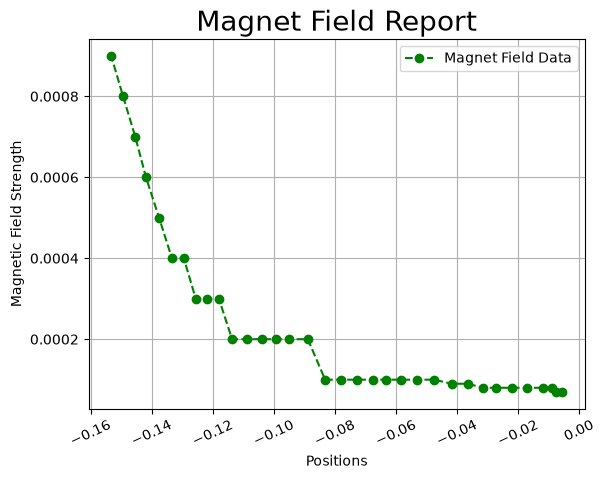

In [2]:
import matplotlib.pyplot as plt
import csv


x = []
y = []


seen_positions = set()
limit = 300
count = 0

with open('Magnet Cube Field measurement.csv', 'r') as csvfile:
    lines = csv.reader(csvfile, delimiter=',')
    for i, row in enumerate(lines):
        if i <= 58 or i >= (58 + limit):
            continue

        try:
            value = abs(float(row[1]))
        except (ValueError, IndexError):
            continue

        if value == 0:
            continue

        position_value = abs(float(row[9]))
        if position_value not in seen_positions:
            seen_positions.add(position_value)
            x.append(-position_value)
            y.append(value)
            count += 1

            if count >= limit:
                break

plt.plot(
    x,
    y,
    color='g',
    linestyle='dashed',
    marker='o',
    label='Magnet Field Data'
)

plt.xticks(rotation=25)
plt.xlabel('Positions')
plt.ylabel('Magnetic Field Strength')
plt.title('Magnet Field Report', fontsize=20)
plt.grid()
plt.legend()
plt.show()

AI prompt: why is the code still giving a really big graph?

Answer: The current loop is still adding data from every row in the range, so I’m tracing that part of the notebook and simplifying it to the intended limit.

I’ve isolated the issue to the nested loop, and I’m replacing it with a single pass so the graph only collects the intended subset.

The graph is still large because the earlier loop was nested incorrectly and was effectively re-reading rows in a way that kept adding points. The uppositiond version uses one clean pass over the CSV and stops after 250 unique, non-zero entries, so it should produce a much smaller plot.

1.3066764018632893 4.6966304033211e-05


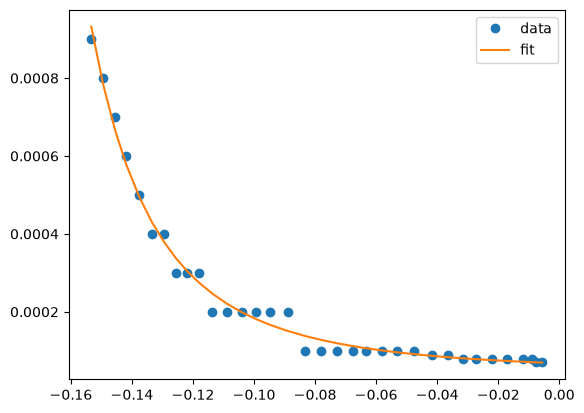

In [ ]:

from scipy.optimize import curve_fit

import numpy as np



def B_z(x, B, B0):
    a = 0.005
    x = x+0.215
    y = -np.arctan(
        a**2 / ((x + a) * np.sqrt(2 * a**2 + (x + a) ** 2))
    ) + np.arctan(a**2 / ((x - a) * np.sqrt(2 * a**2 + (x - a) ** 2)))
    y *= B/np.pi
    return y+B0 


parameters, covariance = curve_fit(B_z, x, y, p0 = [1.345,0])

fitted_rem = parameters[0]
fitted_noise = parameters[1]
print(fitted_rem, fitted_noise)

fit_y = []

for i in x:
    fit_y.append(B_z(i, fitted_rem, fitted_noise))

plt.plot(x, y, 'o', label='data')
plt.plot(x, fit_y, '-', label='fit')
plt.legend()

Remenance magnetism: Cylinder 4.5 cm Diameter

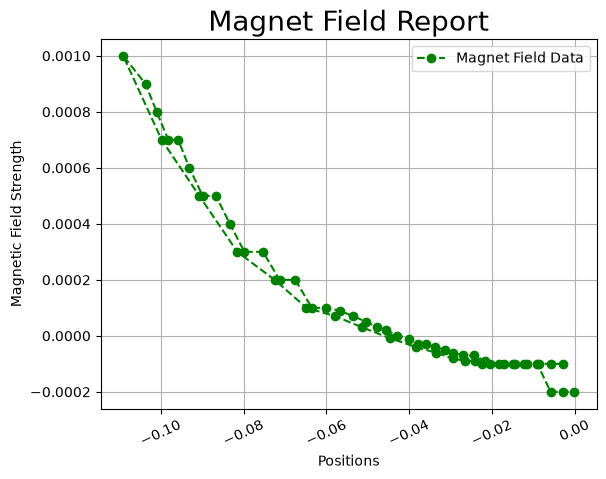

In [4]:
import matplotlib.pyplot as plt
import csv


x = []
y = []


seen_positions = set()
limit = 300
count = 0

with open('Magnet Cylinder Field measurement 4.5 cm d.csv', 'r') as csvfile:
    lines = csv.reader(csvfile, delimiter=',')
    for i, row in enumerate(lines):
        if i <= 58 or i >= (58 + limit):
            continue

        try:
            value = (float(row[12]))
        except (ValueError, IndexError):
            continue

        if value == 0:
            continue

        position_value = abs(float(row[6]))
        if position_value not in seen_positions:
            seen_positions.add(position_value)
            x.append(-position_value)
            y.append(value)
            count += 1

            if count >= limit:
                break

plt.plot(
    x,
    y,
    color='g',
    linestyle='dashed',
    marker='o',
    label='Magnet Field Data'
)

plt.xticks(rotation=25)
plt.xlabel('Positions')
plt.ylabel('Magnetic Field Strength')
plt.title('Magnet Field Report', fontsize=20)
plt.grid()
plt.legend()
plt.show()

1.2147537257080219 -0.0002926213962584311


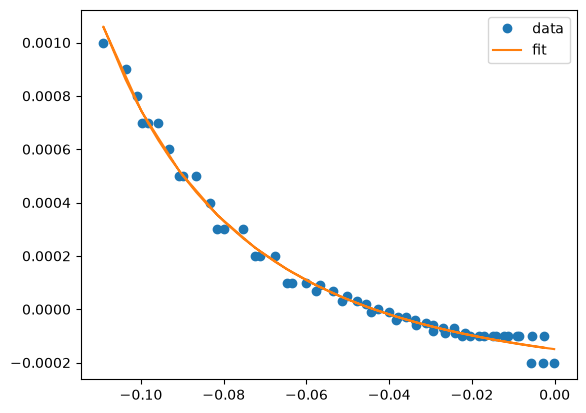

In [5]:
import math
from scipy.optimize import curve_fit

import numpy as np

B_z_array = []

R_full = 0.045/2

import numpy as np


def B_z(z, B_r, B_0):
    R_1 = R_full
    z = z + 0.205
    fraction1 = z / np.sqrt(z**2 + R_1**2) - (z - 0.004) / np.sqrt((z - 0.004) ** 2 + R_1**2)

    fraction2 = z / np.sqrt(z**2 + (0.0045/2)**2) - (z - 0.004) / np.sqrt((z - 0.004) ** 2 + (0.0045/2)**2)

    return (B_r / 2.0) * (fraction1 - fraction2) + B_0


parameters, covariance = curve_fit(B_z, x, y, p0 = [1.19,0])

fitted_rem = parameters[0]
fitted_noise = parameters[1]
print(fitted_rem, fitted_noise)

fit_y = []

for i in x:
    fit_y.append(B_z(i, fitted_rem, fitted_noise))

plt.plot(x, y, 'o', label='data')
plt.plot(x, fit_y, '-', label='fit')
plt.legend()